In [15]:
import pandas as pd
import io
import os
from supabase import create_client
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_SERVICE_KEY"))

data = supabase.storage.from_("silver").download("bikes/latest.parquet")
df = pd.read_parquet(io.BytesIO(data))

df.head()


,id_x,station_id,status,bikes,stands,mechanical_bikes,electrical_bikes,recorded_at,id_y,number,name,latitude,longitude,capacity,recorded_at_local,temperature,wind_speed,rain,condition
0,0ba85318-6b49-4cc2-929d-40ca4fab98c3,3486702b-387e-4ff2-9727-94933fff2c5a,OPEN,11,9,11,0,2026-05-14 14:08:24.788062+00:00,3486702b-387e-4ff2-9727-94933fff2c5a,24,"VZAJEMNA, VARUH ZDRAVJA - BETNAVSKA C.",46.541990,15.638310,20,2026-05-14 16:08:24.788062+02:00,11.8,2.06,0.0,Clouds
1,f9e5a0ee-c117-44b0-b395-7cca546f9c8b,de97e810-60d3-4293-a1ec-28080674b0fd,OPEN,5,15,5,0,2026-05-14 14:08:24.788062+00:00,de97e810-60d3-4293-a1ec-28080674b0fd,8,RAZLAGOVA UL. - OBČINA,46.561960,15.650235,20,2026-05-14 16:08:24.788062+02:00,11.8,2.06,0.0,Clouds
2,479b8078-9080-4b0e-b2a8-1ac8fa3796e5,dc64b706-ec48-48b7-8ae7-e5e6618ce5b4,OPEN,7,13,7,0,2026-05-14 14:08:24.788062+00:00,dc64b706-ec48-48b7-8ae7-e5e6618ce5b4,7,PARTIZANSKA C. - TIC,46.560227,15.650781,20,2026-05-14 16:08:24.788062+02:00,11.8,2.06,0.0,Clouds
3,d52fbea2-0fc1-4618-a18d-903e5974c859,1d49a095-1d27-4538-98b6-d1ca5f11cfcc,OPEN,9,13,9,0,2026-05-14 14:08:24.788062+00:00,1d49a095-1d27-4538-98b6-d1ca5f11cfcc,2,GOSPOSVETSKA C. - VRBANSKA C.,46.561422,15.637118,22,2026-05-14 16:08:24.788062+02:00,11.8,2.06,0.0,Clouds
4,9d735d5a-06a3-4cfd-99c0-73184c86b2a0,d15c5342-ddfd-4542-b720-2a124b9e62e4,OPEN,14,6,14,0,2026-05-14 14:08:24.788062+00:00,d15c5342-ddfd-4542-b720-2a124b9e62e4,32,ZAVAROVALNICA SAVA - JADRANSKA CESTA,46.540351,15.644643,20,2026-05-14 16:08:24.788062+02:00,11.8,2.06,0.0,Clouds


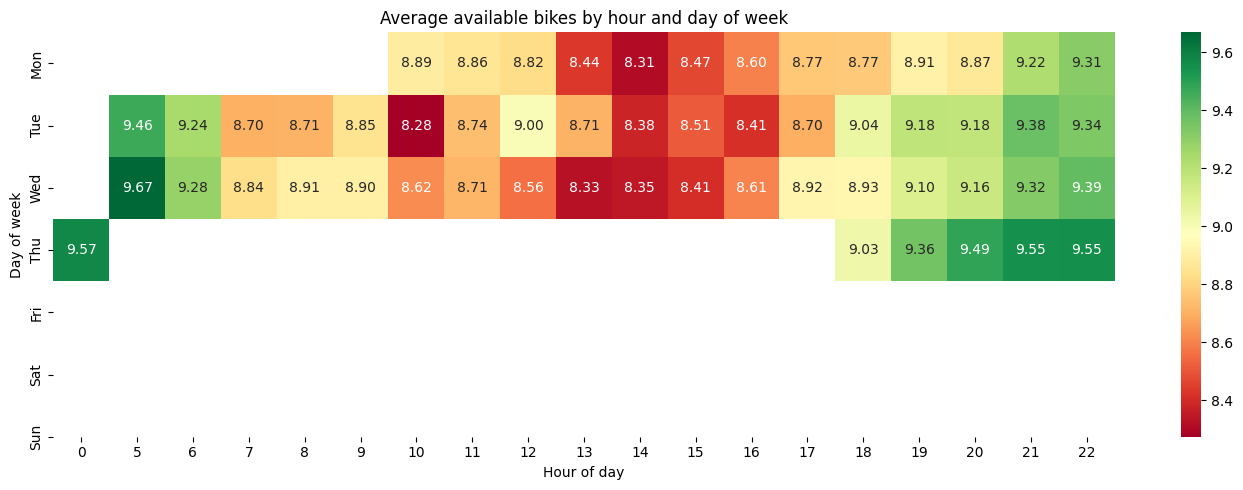

In [16]:
df["hour"] = df["recorded_at_local"].dt.hour
df["day_of_week"] = df["recorded_at_local"].dt.dayofweek  # 0=Mon, 6=Sun

pivot = df.groupby(["day_of_week", "hour"])["bikes"].mean().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, 
            cmap="RdYlGn",
            annot=True, 
            fmt=".2f",
            yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("Average available bikes by hour and day of week")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()



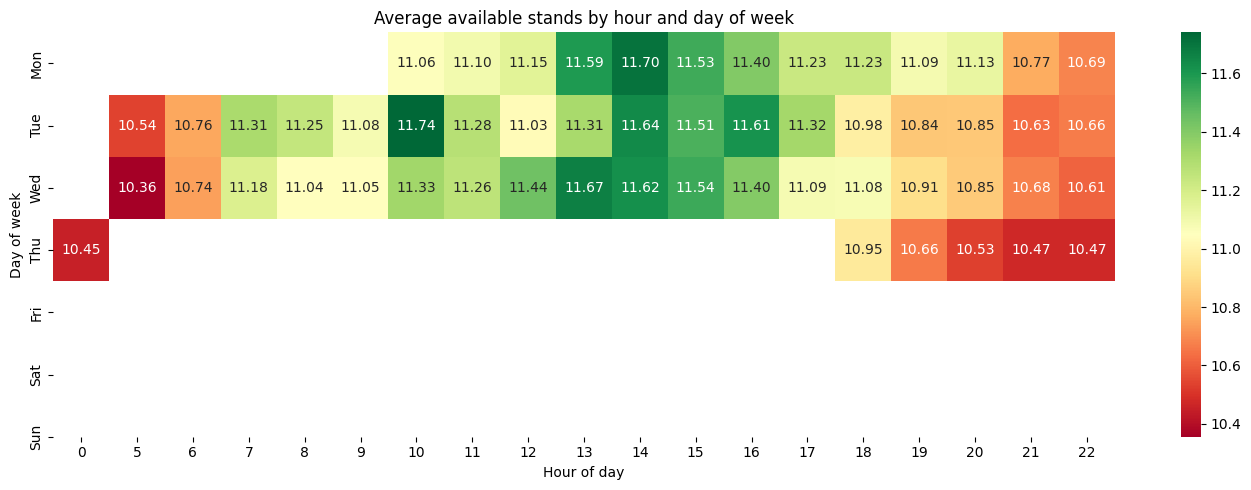

In [17]:
df["hour"] = df["recorded_at_local"].dt.hour
df["day_of_week"] = df["recorded_at_local"].dt.dayofweek  # 0=Mon, 6=Sun

pivot = df.groupby(["day_of_week", "hour"])["stands"].mean().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, 
            cmap="RdYlGn",
            annot=True, 
            fmt=".2f",
            yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("Average available stands by hour and day of week")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()



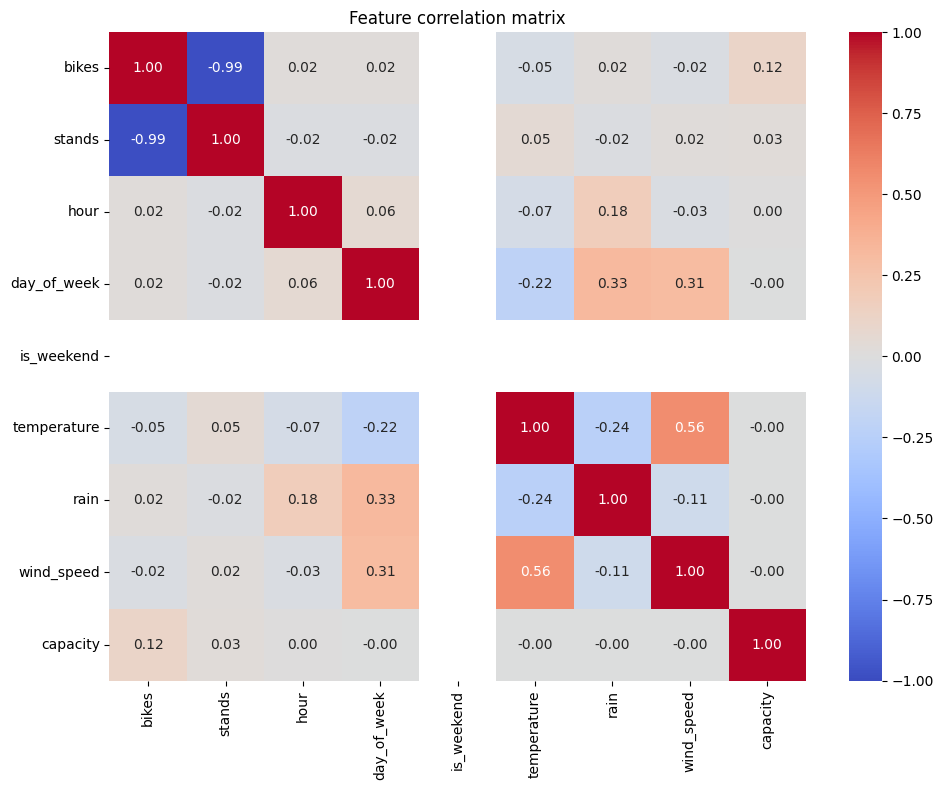

In [18]:
df["recorded_at_local"] = pd.to_datetime(df["recorded_at_local"])
df["hour"]       = df["recorded_at_local"].dt.hour
df["day_of_week"] = df["recorded_at_local"].dt.dayofweek
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

cols = ["bikes", "stands", "hour", "day_of_week", "is_weekend", 
        "temperature", "rain", "wind_speed", "capacity"]

corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            vmin=-1, vmax=1,
            center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


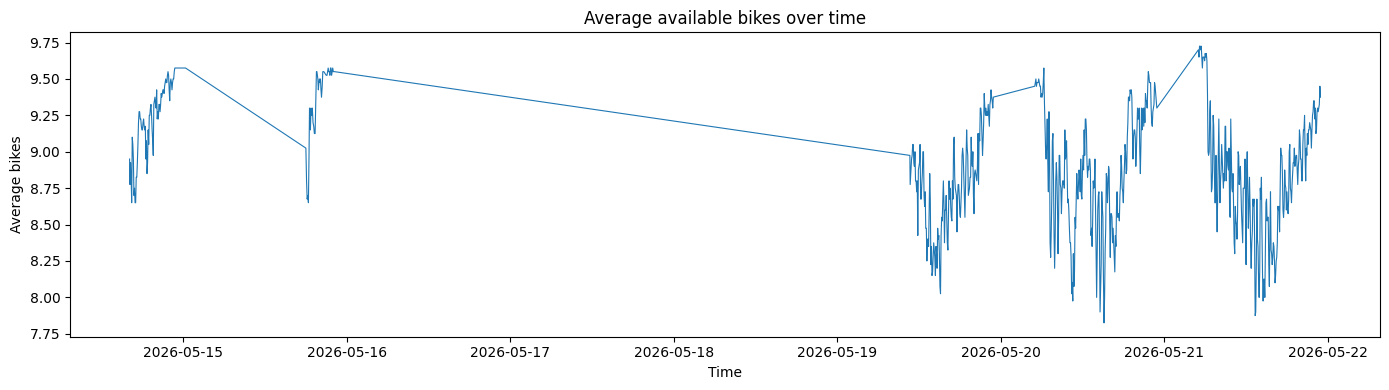

In [19]:
daily = df.groupby("recorded_at_local")["bikes"].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, linewidth=0.8)
plt.title("Average available bikes over time")
plt.xlabel("Time")
plt.ylabel("Average bikes")
plt.tight_layout()
plt.show()


In [20]:
df["date"] = df["recorded_at_local"].dt.date
print(df.groupby("date").size())


date
2026-05-14    3360
2026-05-15    1920
2026-05-19    5920
2026-05-20    8640
2026-05-21    8640
dtype: int64


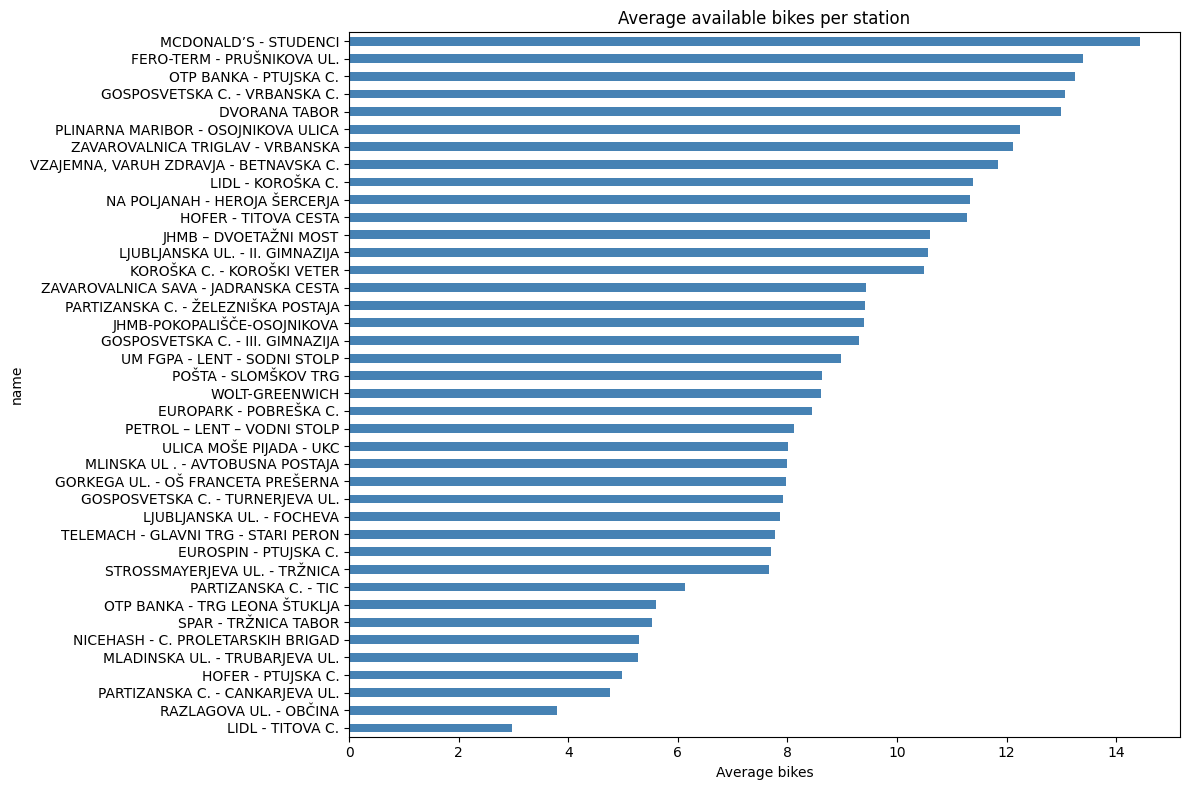

In [21]:
station_avg = df.groupby("name")["bikes"].mean().sort_values()

plt.figure(figsize=(12, 8))
station_avg.plot(kind="barh", color="steelblue")
plt.title("Average available bikes per station")
plt.xlabel("Average bikes")
plt.tight_layout()
plt.show()


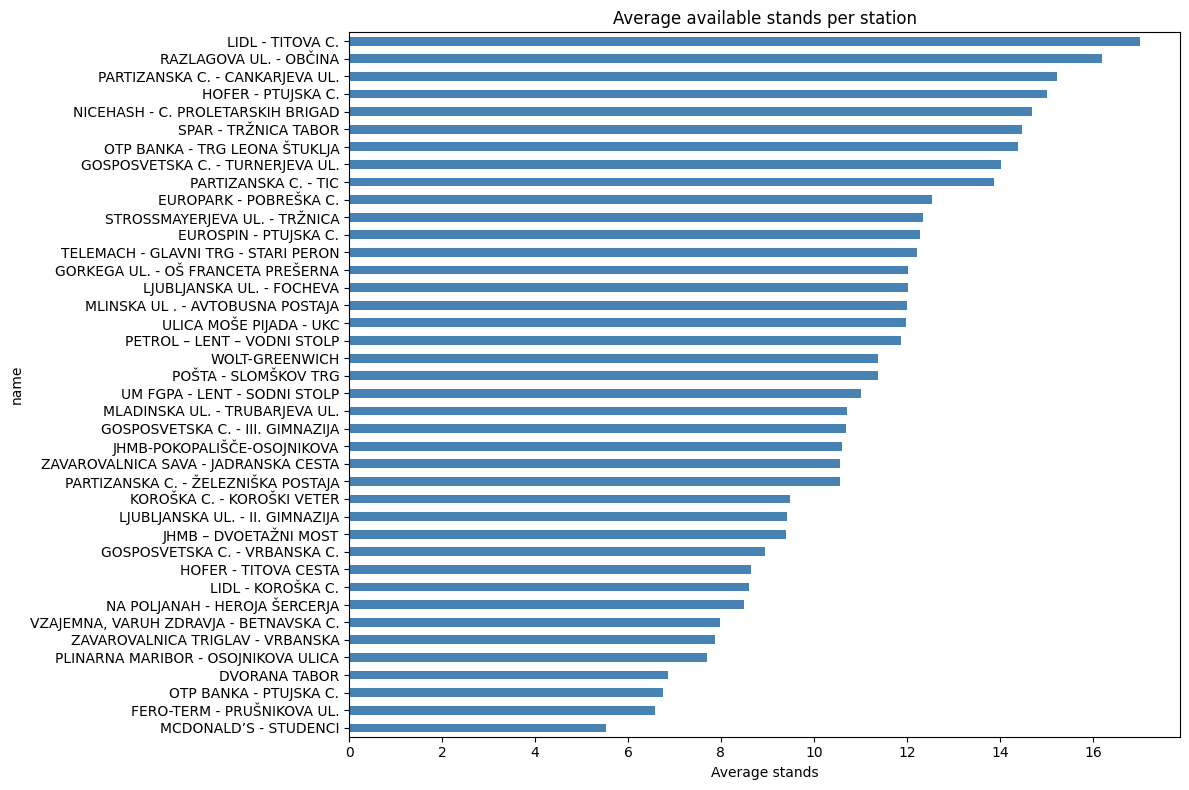

In [22]:
station_avg = df.groupby("name")["stands"].mean().sort_values()

plt.figure(figsize=(12, 8))
station_avg.plot(kind="barh", color="steelblue")
plt.title("Average available stands per station")
plt.xlabel("Average stands")
plt.tight_layout()
plt.show()


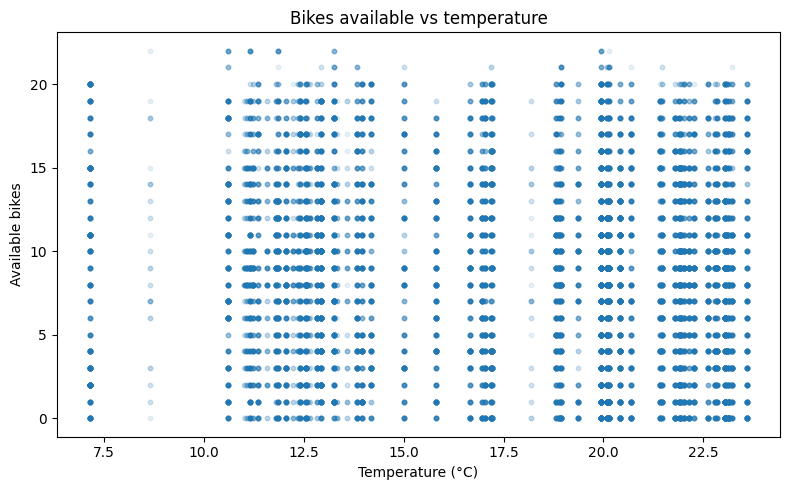

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temperature"], df["bikes"], alpha=0.1, s=10)
plt.title("Bikes available vs temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Available bikes")
plt.tight_layout()
plt.show()
